# Get the data needed for DeepSTARR 
to do: </br>
    - other data augmentation </br>
    - other normalisation method, see below </br>
Done:  </br> 
    - Try with log normalisation --> Tricky to evaluate, the base pair scores look better, but the overall correlations are slightly lower. Maybe would be improved by performing the same normalisation but without the log transformation, and scaling by a factor that gets numbers in the 0 - 5 range </br> 

In [72]:
here::i_am("atac/archR/DeepSTARR/Differential_ATAC.ipynb")

#####################
## Define settings ##
#####################

source(here::here("settings.R"))
source(here::here("utils.R"))
suppressPackageStartupMessages({
    library(BSgenome.Mmusculus.UCSC.mm10)
    library(parallel)
})

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [73]:
# Options
args = list()

# ATAC
args$differential_ATAC = file.path(io$basedir, '/results/rna_atac/differential/Accessibility/DARs_edgeR_pb_lax.txt.gz')

args$outdir = file.path(io$basedir, 'results/atac/archR/DeepSTARR/differential_atac/')
dir.create(args$outdir, recursive=T, showWarnings=F)

In [74]:
DARs = fread(args$differential_ATAC)

In [75]:
unique(DARs$celltype)

[1] "Early_Mes_EOd"       "Primitive_Streak"    "HE"                 
 [4] "Posterior_Mes"       "Mesenchyme"          "Early_Mes_EOi"      
 [7] "Allantois"           "Allantois_Precursor" "HE_Precursor"       
[10] "Endothelium"

In [76]:
DARs_subset = DARs[celltype %in% c('Posterior_Mes', 'Early_Mes_EOd', 'Mesenchyme')] %>%
    .[!is.na(logFC)]

In [77]:
length(unique(DARs_subset$peak))

[1] 189773

In [137]:
head(DARs_subset[order(logFC)])

peak,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr4:109797375-109797975,-5.368,6.13e-20,2.11,0.10,0.06,0.01,Early_Mes_EOd
chr2:57613684-57614284,-4.908,1.51e-15,1.77,0.11,0.05,0.01,Early_Mes_EOd
chr10:70452581-70453181,-4.708,8.00e-23,2.35,0.20,0.07,0.01,Early_Mes_EOd
chr13:36524915-36525515,-4.475,6.74e-16,1.86,0.15,0.05,0.01,Early_Mes_EOd
chr11:34472748-34473348,-4.443,1.59e-15,1.65,0.13,0.05,0.00,Mesenchyme
chr17:65785491-65786091,-4.141,1.21e-12,1.45,0.12,0.05,0.01,Mesenchyme


In [109]:
# Split data in train, val, and test sets
# Before did it with the sample function, but this results in different peaks every time
# all_peaks = rownames(Peakmatrix_filt)
# paste0('total peaks: ', length(all_peaks))
# tot_peaks = length(all_peaks)
# val_peaks = sample(all_peaks, tot_peaks/12)
# paste0('peaks in val set: ', length(val_peaks))
# train_peaks = all_peaks[!all_peaks%in%val_peaks]
# paste0('peaks without validation set: ', length(train_peaks))
# test_peaks = sample(train_peaks, tot_peaks/12)
# paste0('peaks in test set: ', length(test_peaks))
# train_peaks = train_peaks[!train_peaks%in%test_peaks]
# paste0('peaks without validation & test set: ', length(train_peaks))

# Train and validation are around 1/10th of train set

all_peaks = unique(DARs_subset$peak)
all_peaks = all_peaks[sample(length(all_peaks))]
paste0('total peaks: ', length(all_peaks))
tot_peaks = length(all_peaks)
val_test = tot_peaks/10
val_peaks = all_peaks[sample(val_test)]
paste0('peaks in val set: ', length(val_peaks))
train_peaks = all_peaks[!all_peaks%in%val_peaks]
paste0('peaks without validation set: ', length(train_peaks))
test_peaks = all_peaks[val_test+1:val_test*2]
paste0('peaks in test set: ', length(test_peaks))
train_peaks = train_peaks[!train_peaks%in%test_peaks]
paste0('peaks without validation & test set: ', length(train_peaks))

[1] "total peaks: 189773"

[1] "peaks in val set: 18977"

[1] "peaks without validation set: 170796"

[1] "peaks in test set: 18977"

[1] "peaks without validation & test set: 151819"

### Define functions

In [126]:
# transform peaks to 249 bp flanking centre
# Little bit different than DeepSTARR paper, where they also take regions flanking the centre, but would need to recalculate the accessibility of the new bins
parse_peaks = function(peaks){
    data.table(peak=peaks,
               chr=strsplit(peaks, ':') %>% map_chr(1),
               start=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1)),
               end=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2))) %>%
    .[,centre:=round((start+end)/2, 0)] %>% # Get centre of peak and round in case original peak width was an odd number
    .[,`:=`(start=NULL,end=NULL)] %>%
    .[,`:=`(start = centre - 124,
            end = centre + 124)] %>%
    .[,new_peak:=paste0(chr, ':', start, '-', end)]
}

# prepare fasta file
get_fa = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # negative strand
    neg_peak = paste0('>', peakset[x,new_peak], '_-')
    neg_fa = paste(as.character(as.vector(reverseComplement(DNAString(pos_fa)))), collapse="")
    
    # return
    tmp = c(pos_peak, pos_fa, neg_peak, neg_fa)
    return(tmp)
}

## Get fasta files

In [127]:
########################
### Get & save Fastas ##
########################

# Train set
train_peakset = parse_peaks(train_peaks)
train_fa = mclapply(1:nrow(train_peakset), get_fa, peakset=train_peakset, mc.cores=24) %>% unlist()
writeLines(train_fa , sprintf('%s/train.fa', args$outdir))

In [128]:
# Validation set
val_peakset = parse_peaks(val_peaks)
val_fa = mclapply(1:nrow(val_peakset), get_fa, peakset=val_peakset, mc.cores=24) %>% unlist()
writeLines(val_fa , sprintf('%s/val.fa', args$outdir))

In [129]:
# Test set
test_peakset = parse_peaks(test_peaks)
test_fa = mclapply(1:nrow(test_peakset), get_fa, peakset=test_peakset, mc.cores=24) %>% unlist()
writeLines(test_fa , sprintf('%s/test.fa', args$outdir))

## Get scores

In [130]:
# get peak sets (after reloading notebook)
train_peakset = parse_peaks(train_peaks)
val_peakset = parse_peaks(val_peaks)
test_peakset = parse_peaks(test_peaks)

In [131]:
train = DARs[match(train_peaks, peak)]

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 38584 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 4999 rows containing non-finite values (`stat_bin()`).”


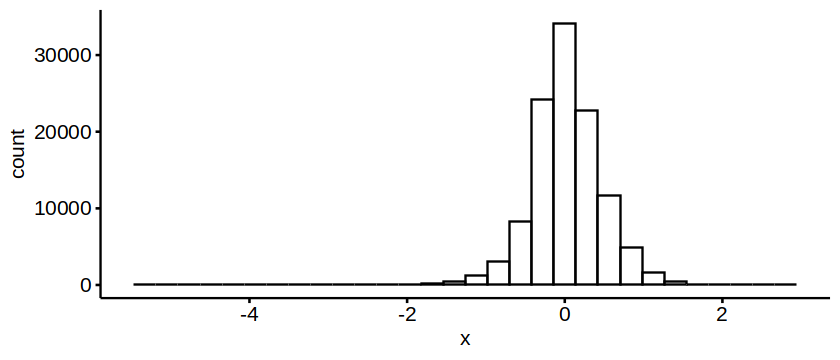

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 4843 rows containing non-finite values (`stat_bin()`).”


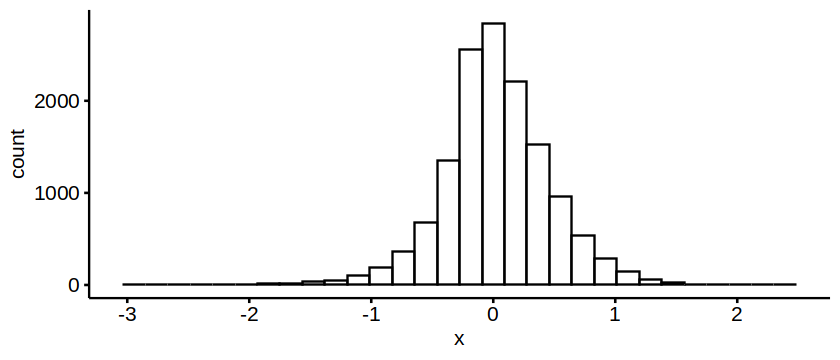

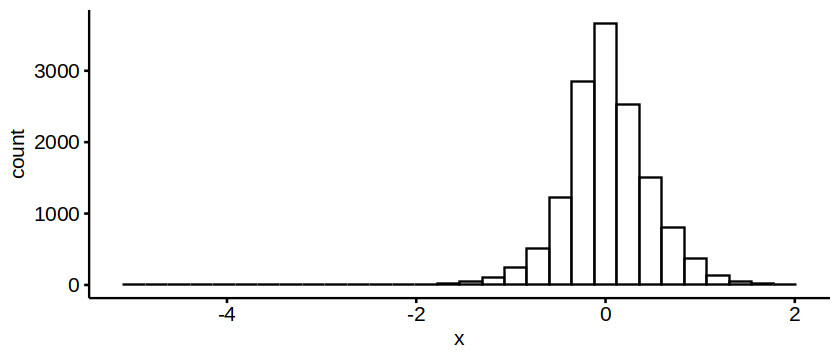

In [132]:
options(repr.plot.height=3)
gghistogram(DARs[match(train_peaks, peak)][,logFC])
gghistogram(DARs[match(val_peaks, peak)][,logFC])
gghistogram(DARs[match(test_peaks, peak)][,logFC])

In [133]:
head(train_peaks)

[1] "chr4:150066607-150067207"  "chr8:127579333-127579933" 
[3] "chr1:180119760-180120360"  "chr1:167240305-167240905" 
[5] "chr3:87974216-87974816"    "chr11:100153749-100154349"

In [134]:
train_sequence_activity = DARs_subset %>% 
    dcast(peak ~ celltype, value.var='logFC') %>%
    .[match(rep(train_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  

In [135]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
DARs.mtx = DARs_subset %>% 
    dcast(peak ~ celltype, value.var='logFC') 

train_sequence_activity = DARs.mtx %>%
    .[match(rep(train_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(train_sequence_activity,  sprintf('%s/train_sequence_activity_log.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = DARs.mtx %>%
    .[match(rep(val_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(val_sequence_activity,  sprintf('%s/val_sequence_activity_log.txt', args$outdir), sep = '\t')

# Test set
test_sequence_activity = DARs.mtx %>%
    .[match(rep(test_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(test_sequence_activity,  sprintf('%s/test_sequence_activity_log.txt', args$outdir), sep = '\t')

In [136]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
DARs.mtx = DARs_subset %>% 
    dcast(peak ~ celltype, value.var='logFC') 

train_sequence_activity = DARs.mtx %>%
    .[match(rep(train_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(scale(train_sequence_activity),  sprintf('%s/train_sequence_activity_log_scaled.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = DARs.mtx %>%
    .[match(rep(val_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(scale(val_sequence_activity),  sprintf('%s/val_sequence_activity_log_scaled.txt', args$outdir), sep = '\t')

# Test set
test_sequence_activity = DARs.mtx %>%
    .[match(rep(test_peaks, each=2), peak)] %>%
    .[,peak:=NULL] %>% 
    setnafill(., fill = 0)  
fwrite(scale(test_sequence_activity),  sprintf('%s/test_sequence_activity_log_scaled.txt', args$outdir), sep = '\t')

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table



#### Inspection fastas

In [90]:
################################
### Get Fastas for inspection ##
################################
# prepare fasta file
get_fa_ss = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # return
    tmp = c(pos_peak, pos_fa)
    return(tmp)
}

In [91]:

# up peaks
up_peaks = head(DARs_subset[order(-logFC), peak], 50)
peaks_tmp = parse_peaks(up_peaks)
fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=24) %>% unlist()
writeLines(fa_tmp , sprintf('%s/up_markers.fa', args$outdir))  

In [92]:
# up peaks
down_peaks = head(DARs_subset[order(logFC), peak], 50)
peaks_tmp = parse_peaks(up_peaks)
fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=24) %>% unlist()
writeLines(fa_tmp , sprintf('%s/up_markers.fa', args$outdir))  